In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df =  pd.read_csv(r'C:\Users\indur\OneDrive\Desktop\power bi projects\Public_Transport_Delay\public_transport_delay_cleaned.csv')
df.to_string(max_cols=None)
df


,Unnamed: 0,TRIP_ID,CITY,ROUTE_ID,HOUR,DAY_OF_WEEK,RAINFALL_MM,TEMPERATURE,HUMIDITY,WIND_SPEED,RUSH_HOUR,TRAFFIC_LEVEL,EVENT_TODAY,EVENT_TYPE,IS_WEEKEND,VEHICLE_TYPE,DELAY_MINUTES
0,0,TR1,Hyderabad,Busss88,4,Saturday,9.9,28.0,79.0,15km/h,Yes,Low_Traffic,Yes,NaN,NO,Metro,16min
1,1,TR2,Delhi,Busss55,20,Saturday,6.7.7,34.0,52.0,9km/h,No,Medium_Traffic,Yes,IPL_Match,YES,Bus,19min
2,2,TR3,Chennai,Local_Train,10,Saturday,1.3,25.0,93.0,13km/h,Yes,Low_Traffic,Yes,Cricket_Match,NO,Bus,7min
3,3,TR4,Hyderabad,Local_Train,3,Friday,5.7,28.0,66.0,15km/h,Yes,Low_Traffic,Yes,NaN,NO,Train,17min
4,4,TR5,Chennai,Busss55,3,Sunday,6.9.9,35.5,56.0,11km/h,Yes,Medium_Traffic,No,NaN,YES,Bus,13min
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,44995,TR44996,Delhi,Metrored,14,Sunday,7.2,32.0,88.8,99km/h,No,High_Traffic,Yes,Concert,NO,Bus,19min
44996,44996,TR44997,Chennai,Busss88,2,Monday,8.7.7,34.4,78.8,8km/h,Yes,High_Traffic,Yes,Concert,YES,Metro,22min
44997,44997,TR44998,Mumbai,Metrored,12,Wednesday,2.1.1,27.0,84.0,8km/h,Yes,High_Traffic,Yes,Concert,NO,Bus,33min
44998,44998,TR44999,Delhi,Busss88,15,Saturday,4.9.9,27.0,52.0,88km/h,Yes,Medium_Traffic,Yes,IPL_Match,NO,Train,16min


In [ ]:
print('.............................................Exploratory Data Analysis (EDA) on public transport delay dataset...........................')


In [ ]:
#basic information about the dataset
print(df.describe())
print(df.info())
print(df.shape)


In [ ]:
#duplicated_values
duplicates = df.duplicated().sum()
print(f'number of duplicates rows:{duplicates}')


In [ ]:
# null values
print(df.isna().sum())

In [ ]:
# understanding the numerical columns 

num_col = df['DELAY_MINUTES'].value_counts()
num_col

#visulization of numerical columns 

plt.figure(figsize=(10, 10))
sns.histplot(num_col,bins=30,kde= True)
plt.title('Distribution of Delay Minutes')
plt.xlabel('Delay Minutes')
plt.ylabel('Frequency')
plt.show()

In [ ]:
categorical_columns = [df['CITY'], df['DAY_OF_WEEK'], df['VEHICLE_TYPE'], df['TRAFFIC_LEVEL']]

#visiualization of categorical columns
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x = col,data=df)
    plt.title(f'Distribution of {col.name}')
    plt.xlabel(col.name)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [ ]:
# groupby  and aggragation

groupby = df.groupby('CITY')['DELAY_MINUTES'].sum()
print(groupby)

#visualization of groupby and aggragation

plt.figure(figsize=(8,6))
sns.barplot(x=groupby.index, y=groupby.values)
plt.title('Total Delay Minutes by City')
plt.xlabel('City')
plt.ylabel('Total Delay Minutes')
plt.show()

In [ ]:
#vehicle type and delay minutes relationship    
sns.boxplot(x='VEHICLE_TYPE', y='DELAY_MINUTES', data=df)
plt.title(  'Box Plot of Delay Minutes by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Delay Minutes')
plt.show()

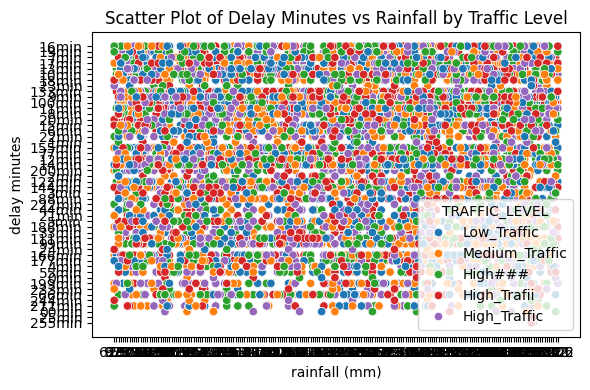

In [4]:
#relationship between traffic level and delay minutes

plt.figure(figsize=(6,4))
sns.scatterplot(x = 'RAINFALL_MM',y ='DELAY_MINUTES',data=df,hue='TRAFFIC_LEVEL')
plt.title('Scatter Plot of Delay Minutes vs Rainfall by Traffic Level')
plt.xlabel('rainfall (mm)')
plt.ylabel('delay minutes')
plt.tight_layout()
plt.show()

In [ ]:
#line chart to show delay minutes over time
plt.figure(figsize=(12,6))
sns.lineplot(x='DAY_OF_WEEK', y='DELAY_MINUTES', data=df)
plt.title('Delay Minutes Over Time')
plt.xlabel('Day of Week')
plt.ylabel('Delay Minutes')
plt.show()

In [ ]:
#Correlation between numerical columns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.xlabel('Numerical Columns')
plt.ylabel('Numerical Columns') 
plt.show()

In [ ]:
# overall relationship between numerical and categorical columns

sns.pairplot(df,hue="CITY")
plt.title('Pair Plot of Numerical Columns by City')
plt.show()


In [ ]:
# overall explanation of the EDA process and insights gained from the analysis about the EDA process and insights gained from the analysis about the public transport delay dataset
print('The EDA process on the public transport delay dataset revealed several insights. The dataset contains')
print(f'- {df.shape[0]} rows and {df.shape[1]} columns')

In [ ]:
#overall process and insight explanation
print('outplot')
print('barplot')
print('lineplot')
print('understanding the numerical columns and categorical columns')
print('overall relationship of the data using pariplot')
print('countplot')
print('correlation heatmap shows that there is a positive correlation between delay minutes and traffic level, indicating that higher traffic levels are associated with longer delays. The pair plot reveals that certain cities experience more delays than others, and the box plot indicates that specific vehicle types may be more prone to delays. The line chart suggests that delays tend to vary throughout the week, with certain days experiencing higher delay minutes. Overall, these insights can help identify patterns and factors contributing to public transport delays, which can inform strategies for improvement.')
print('.............................................................................................................................................................')  
print('End of EDA process') 